# MODELLING



**Models Implemented:**
1. **SVD Collaborative Filtering** — matrix factorisation with bias correction
2. **Content-Based Filtering** — TF-IDF + SVD latent space + cosine similarity
3. **Hybrid Model** — weighted combination of SVD + Content-Based (alpha-tuned)

**Evaluation Metrics (all models):** RMSE · MAE · Precision@5 · Recall@5 · NDCG@5 · HitRate@5


### Importing Neccessary Libraries

In [42]:
# IMPORTING NECCESSARY LIBRARIES
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt

from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

warnings.filterwarnings('ignore')
np.random.seed(42)



In [43]:
# 1.1  Load raw data 
df = pd.read_csv('final_dataset.csv')

print(f"shape: {df.shape}")
print("\nMissing values:")
print(df.isna().sum())

shape: (321026, 24)

Missing values:
userid                    0
movieid                   0
rating                    0
timestamp                 0
clean_title               0
id                        0
vote_average              0
vote_count                0
release_date          58883
revenue                   0
runtime                   0
adult                     0
budget                    0
imdb_id              123545
original_language         0
original_title            0
overview              38730
popularity                0
tagline              203265
keywords             179112
genres                    0
release_year              0
language_name         15487
content                   0
dtype: int64


In [44]:
# Drop rows with missing user, movie, or rating — mandatory columns
df = df.dropna(subset=['userid', 'movieid', 'rating'])

# Enforce integer IDs
df['userid']  = df['userid'].astype(int)
df['movieid'] = df['movieid'].astype(int)

# Clean / normalise movie titles for lookups
df['clean_title'] = df['clean_title'].str.lower().str.strip()

In [45]:

RATING_MIN, RATING_MAX = 1.0, 5.0   # canonical scale — used everywhere
K = 5                                 # top-K for ranking metrics

# Clip ratings to the canonical 1–5 scale (removes any 0s or out-of-range values)
df['rating'] = df['rating'].clip(RATING_MIN, RATING_MAX)



# Fill text metadata columns used by content-based model
text_cols = ['overview', 'keywords', 'genres', 'tagline', 'language_name']
for col in text_cols:
    if col in df.columns:
        df[col] = df[col].fillna('')

# Build boosted content column (genres and keywords weighted higher)
df['content'] = (
    df['overview']       + ' ' +
    df['genres']         + ' ' * 3 +   # 3× boost
    df['keywords']       + ' ' * 2 +   # 2× boost
    df['tagline']        + ' ' +
    df['language_name']
)

print(f"Clean shape: {df.shape}")
print(f"Rating range: [{df.rating.min()}, {df.rating.max()}]")
print(f"Unique users: {df.userid.nunique()} | Unique movies: {df.movieid.nunique()}")

Clean shape: (321026, 24)
Rating range: [1.0, 5.0]
Unique users: 610 | Unique movies: 6834


In [46]:
ratings = df[['userid', 'movieid', 'rating']].copy()

# IMPORTANT: preserve original index for leakage check
ratings = ratings.reset_index()  # keeps original row id in 'index' column

# Split
train_data, temp_data = train_test_split(ratings, test_size=0.30, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.50, random_state=42)


# Now safe to drop index for modeling
train_data = train_data.drop(columns=['index']).reset_index(drop=True)
val_data   = val_data.drop(columns=['index']).reset_index(drop=True)
test_data  = test_data.drop(columns=['index']).reset_index(drop=True)

In [47]:
# ── 1.4  Training-set statistics (used by all models) ─────────────────────────
#  Computed from train_data ONLY — never from val or test.

global_mean  = train_data['rating'].mean()
user_biases  = train_data.groupby('userid')['rating'].mean()  - global_mean
item_biases  = train_data.groupby('movieid')['rating'].mean() - global_mean
movie_mean   = train_data.groupby('movieid')['rating'].mean()   # for cold-start
user_mean    = train_data.groupby('userid')['rating'].mean()    # for cold-start

print(f"Global mean rating (train): {global_mean:.4f}")

Global mean rating (train): 3.4736



## Model 1: SVD Collaborative Filtering

**Approach:**  
1. Normalise ratings by removing global mean + user bias + item bias  
2. Apply Truncated SVD to the doubly-normalised user-item matrix  
3. At prediction time, reconstruct: `ŷ = global_mean + user_bias + item_bias + latent_pred`  
4. Clip to [1, 5]

**Evaluation uses `test_data` only.**

In [48]:
# Build doubly-normalised training matrix 

train_data_norm = train_data.copy()
train_data_norm['rating'] = train_data_norm.apply(
    lambda r: r['rating']
              - global_mean
              - user_biases.get(r['userid'],  0)
              - item_biases.get(r['movieid'], 0),
    axis=1
)

train_matrix = train_data_norm.pivot_table(
    index='userid', columns='movieid', values='rating'
).fillna(0)

print(f"Training matrix: {train_matrix.shape}  (users × movies)")

Training matrix: (610, 6341)  (users × movies)


In [49]:
# Fit SVD
#  n_components = 600 latent factors (as in original)

N_COMPONENTS = min(600, min(train_matrix.shape) - 1)  # guard for small datasets

svd_model = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
U  = svd_model.fit_transform(train_matrix)
Vt = svd_model.components_

pred_matrix_norm = U @ Vt
pred_df = pd.DataFrame(
    pred_matrix_norm,
    index=train_matrix.index,
    columns=train_matrix.columns
)

print(f"SVD fitted — {N_COMPONENTS} components")
print(f"Explained variance: {svd_model.explained_variance_ratio_.sum():.2%}")

SVD fitted — 600 components
Explained variance: 99.99%


In [50]:
# SVD prediction function 

def svd_predict(user_id: int, movie_id: int) -> float:
    """
    Return a predicted rating on the 1–5 scale.

    Formula:
        ŷ = global_mean + user_bias + item_bias + latent_pred

    Falls back to global_mean when user or movie was unseen in training.
    Output is always clipped to [RATING_MIN, RATING_MAX].
    """
    if user_id not in pred_df.index or movie_id not in pred_df.columns:
        return float(global_mean)  # unseen → fallback

    latent = pred_df.loc[user_id, movie_id]
    pred   = (global_mean
              + user_biases.get(user_id,  0)
              + item_biases.get(movie_id, 0)
              + latent)

    return float(np.clip(pred, RATING_MIN, RATING_MAX))

In [51]:
# Shared ranking metric utilities
# These functions are reused across all three models.

def compute_ndcg(relevance: list, k: int) -> float:
    """Normalised Discounted Cumulative Gain at k."""
    dcg  = sum(r / np.log2(i + 2) for i, r in enumerate(relevance[:k]))
    idcg = sum(r / np.log2(i + 2) for i, r in enumerate(sorted(relevance, reverse=True)[:k]))
    return dcg / idcg if idcg > 0 else 0.0


def ranking_metrics(predict_fn, data: pd.DataFrame, k: int = 5,
                    threshold: float = 4.0) -> dict:
    
    precisions, recalls, hits, ndcgs = [], [], [], []

    for user_id, group in data.groupby('userid'):
        if len(group) < 2:
            continue

        relevant_movies = set(group.loc[group['rating'] >= threshold, 'movieid'])
        if len(relevant_movies) == 0:
            continue

        # Score all movies this user interacted with in the evaluation set
        candidates = group['movieid'].tolist()

        scored = sorted(
            [(m, predict_fn(user_id, m)) for m in candidates],
            key=lambda x: x[1], reverse=True
        )

        top_k = [m for m, _ in scored[:k]]
        relevance = [1 if m in relevant_movies else 0 for m in top_k]

        n_relevant_total = len(relevant_movies)

        precisions.append(sum(relevance) / k)
        recalls.append(sum(relevance) / n_relevant_total)
        hits.append(int(any(relevance)))
        ndcgs.append(compute_ndcg(relevance, k))

    return {
        f'Precision@{k}': np.mean(precisions),
        f'Recall@{k}':    np.mean(recalls),
        f'HitRate@{k}':   np.mean(hits),
        f'NDCG@{k}':      np.mean(ndcgs),
    }

In [52]:
# 2.4  SVD evaluation on test_data 

svd_preds   = np.array([svd_predict(r.userid, r.movieid) for r in test_data.itertuples()])
svd_actuals = test_data['rating'].values

svd_rmse = np.sqrt(mean_squared_error(svd_actuals, svd_preds))
svd_mae  = mean_absolute_error(svd_actuals, svd_preds)

svd_ranking = ranking_metrics(svd_predict, test_data, k=K)

svd_metrics = {'RMSE': svd_rmse, 'MAE': svd_mae, **svd_ranking}

print("── SVD Collaborative Filtering — Test Metrics ──")
for m, v in svd_metrics.items():
    print(f"  {m:<15}: {v:.4f}")

── SVD Collaborative Filtering — Test Metrics ──
  RMSE           : 0.3430
  MAE            : 0.0980
  Precision@5    : 0.9256
  Recall@5       : 0.6136
  HitRate@5      : 0.9966
  NDCG@5         : 0.9841


In [53]:
def get_movie_id(title: str):
    title = title.lower().strip()
    return title_to_movieid.get(title)

In [54]:
# Create global title mappings (SAFE FIX)
movie_titles = df[['movieid', 'clean_title']].drop_duplicates()

movieid_to_title = dict(zip(movie_titles['movieid'], movie_titles['clean_title']))
title_to_movieid = {v.lower().strip(): k for k, v in movieid_to_title.items()}

In [55]:
def recommend_movies_svd_by_title(title: str, top_k: int = 5):
    movie_id = get_movie_id(title)

    if movie_id is None:
        print("Movie not found in dataset.")
        return []

    # Step 1: find users who liked this movie (from TRAIN data only)
    users_who_liked = train_data[
        (train_data['movieid'] == movie_id) &
        (train_data['rating'] >= 4)
    ]['userid'].unique()

    if len(users_who_liked) == 0:
        print("No users found who liked this movie.")
        return []

    # Step 2: score ALL movies for these users
    movie_scores = {}

    for user in users_who_liked:
        for m in pred_df.columns:
            if m == movie_id:
                continue

            score = svd_predict(user, m)

            if m not in movie_scores:
                movie_scores[m] = []
            movie_scores[m].append(score)

    # Step 3: average scores across users
    avg_scores = {
        m: np.mean(scores)
        for m, scores in movie_scores.items()
    }

    # Step 4: sort and pick top_k
    top_movies = sorted(avg_scores.items(), key=lambda x: x[1], reverse=True)[:top_k]

    # Step 5: convert to titles
    recommendations = [
        (movieid_to_title.get(m, "Unknown"), score)
        for m, score in top_movies
    ]

    return recommendations

In [56]:

recs = recommend_movies_svd_by_title("god fela", top_k=5)

recs_df = pd.DataFrame(recs, columns=["Movie Title", "Predicted Rating"])

print("\nTop 5 Recommendations:\n")
print(recs_df)

Movie not found in dataset.

Top 5 Recommendations:

Empty DataFrame
Columns: [Movie Title, Predicted Rating]
Index: []


## Model 2: Content-Based Filtering

In this part, we build a content-based recommendation system using movie descriptions (overviews). Movie overviews were transformed into numerical features using TF-IDF, which captures the importance of words in each description. Common words were removed, and both single words and word pairs were considered to improve context. 

The resulting matrix represents each movie as a feature vector, enabling similarity-based recommendations.
The idea is to recommend movies that are similar in content by analyzing their textual information rather than relying on user ratings.

In [57]:

movie_content = df.drop_duplicates(subset='movieid').reset_index(drop=True).copy()

# TF-IDF
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2)
)
tfidf_matrix = tfidf.fit_transform(movie_content['content'])

# Dimensionality reduction
content_svd = TruncatedSVD(n_components=100, random_state=42)
reduced_matrix = content_svd.fit_transform(tfidf_matrix)  # shape: (n_movies, 100)

# Cosine similarity
content_similarity = cosine_similarity(reduced_matrix)     # shape: (n_movies, n_movies)

# Index helpers
movieid_to_idx  = {mid: i for i, mid in enumerate(movie_content['movieid'])}
idx_to_movieid  = {i: mid for mid, i in movieid_to_idx.items()}
movieid_to_title = movie_content.set_index('movieid')['clean_title'].to_dict()
title_to_movieid = {v: k for k, v in movieid_to_title.items()}
title_to_idx     = {t: movieid_to_idx[mid] for t, mid in title_to_movieid.items()
                    if mid in movieid_to_idx}

print(f"Content matrix: {reduced_matrix.shape}  (movies × latent dims)")
print(f"Similarity matrix: {content_similarity.shape}")

Content matrix: (6834, 100)  (movies × latent dims)
Similarity matrix: (6834, 6834)


In [58]:
def content_predict(user_id: int, movie_id: int) -> float:
    if movie_id not in movieid_to_idx:
        return float(global_mean)

    if user_id not in user_history_map:
        return float(global_mean)

    target_idx = movieid_to_idx[movie_id]
    history = user_history_map[user_id]

    sims = []
    ratings = []

    for hist_movie, rating in history:
        if hist_movie == movie_id:
            continue
        if hist_movie not in movieid_to_idx:
            continue

        hist_idx = movieid_to_idx[hist_movie]
        sims.append(content_similarity[target_idx, hist_idx])
        ratings.append(rating)

    if len(sims) == 0:
        return float(global_mean)

    sims = np.array(sims)
    ratings = np.array(ratings)

    pred = np.dot(sims, ratings) / (np.sum(sims) + 1e-8)

    return float(np.clip(pred, RATING_MIN, RATING_MAX))

In [59]:
# Build fast lookup: user → list of (movieid, rating)
user_history_map = train_data.groupby('userid').apply(
    lambda x: list(zip(x['movieid'], x['rating']))
).to_dict()

In [60]:
cb_preds = np.array([
    content_predict(u, m)
    for u, m in zip(test_data.userid, test_data.movieid)
])

cb_actuals = test_data['rating'].values

cb_rmse = np.sqrt(mean_squared_error(cb_actuals, cb_preds))
cb_mae  = mean_absolute_error(cb_actuals, cb_preds)

cb_ranking = ranking_metrics(content_predict, test_data, k=K)

cb_metrics = {'RMSE': cb_rmse, 'MAE': cb_mae, **cb_ranking}

print("── Content-Based Filtering — Test Metrics ──")
for m, v in cb_metrics.items():
    print(f"{m:<15}: {v:.4f}")

── Content-Based Filtering — Test Metrics ──
RMSE           : 0.9117
MAE            : 0.7143
Precision@5    : 0.4951
Recall@5       : 0.2891
HitRate@5      : 0.7873
NDCG@5         : 0.6707


In [61]:
def get_movie_idx_from_title(title: str):
    title = title.lower().strip()
    if title not in title_to_idx:
        print("Movie not found.")
        return None
    return title_to_idx[title]

In [62]:
def recommend_movies_content(title: str, top_k: int = 5):
    idx = get_movie_idx_from_title(title)

    if idx is None:
        return []

    # Get similarity scores for this movie
    sim_scores = content_similarity[idx]

    # Get top similar movie indices (excluding itself)
    similar_indices = np.argsort(sim_scores)[::-1][1:top_k+1]

    # Convert to titles
    recommendations = [
        (movieid_to_title[idx_to_movieid[i]], sim_scores[i])
        for i in similar_indices
    ]

    return recommendations

In [63]:
recs = recommend_movies_content("toy story", top_k=5)

recs_df = pd.DataFrame(recs, columns=["Movie Title", "Similarity"])

print("\nTop 5 similar movies (Content-Based):\n")
print(recs_df)


Top 5 similar movies (Content-Based):

       Movie Title  Similarity
0      toy story 2    0.744330
1    kung fu panda    0.635691
2  kung fu panda 3    0.604946
3  kung fu panda 2    0.597735
4     finding dory    0.589172




### Model 3: Hybrid Recommendation Model (SVD + Content-Based)

A hybrid recommendation system combines:

Collaborative Filtering (SVD) which learns from user ratings and
Content-Based Filtering (TF-IDF + Cosine Similarity) which uses movie features


We combine:

1. SVD Prediction Score - “What the user is likely to rate this movie”

2. Content Similarity Score - “How similar the movie is to what the user likes”

In [64]:
def hybrid_predict(user_id: int, movie_id: int, alpha: float = 0.7) -> float:
    svd_score = svd_predict(user_id, movie_id)
    content_score = content_predict(user_id, movie_id)

    blended = alpha * svd_score + (1 - alpha) * content_score
    return float(np.clip(blended, RATING_MIN, RATING_MAX))

In [65]:
DEFAULT_ALPHA = 0.7

hybrid_preds = np.array([
    hybrid_predict(u, m, DEFAULT_ALPHA)
    for u, m in zip(test_data.userid, test_data.movieid)
])

hybrid_actuals = test_data['rating'].values

hyb_rmse = np.sqrt(mean_squared_error(hybrid_actuals, hybrid_preds))
hyb_mae  = mean_absolute_error(hybrid_actuals, hybrid_preds)

hyb_ranking = ranking_metrics(
    lambda u, m: hybrid_predict(u, m, DEFAULT_ALPHA),
    test_data,
    k=K
)

hybrid_metrics_default = {'RMSE': hyb_rmse, 'MAE': hyb_mae, **hyb_ranking}

print(f"── Hybrid (α={DEFAULT_ALPHA}) — Test Metrics ──")
for m, v in hybrid_metrics_default.items():
    print(f"{m:<15}: {v:.4f}")

── Hybrid (α=0.7) — Test Metrics ──
RMSE           : 0.4160
MAE            : 0.2786
Precision@5    : 0.9273
Recall@5       : 0.6117
HitRate@5      : 0.9966
NDCG@5         : 0.9870


In [66]:
def recommend_movies_hybrid(title: str, top_k: int = 5, alpha: float = 0.7):
    title = title.lower().strip()

    if title not in title_to_idx:
        print("Movie not found.")
        return []

    target_idx = title_to_idx[title]
    target_movie_id = idx_to_movieid[target_idx]

    # Step 1: get similarity scores
    sim_scores = content_similarity[target_idx]

    # Step 2: get top candidate movies (more than top_k for better ranking)
    candidate_indices = np.argsort(sim_scores)[::-1][1:50]

    candidate_movie_ids = [idx_to_movieid[i] for i in candidate_indices]

    # Step 3: find users who liked the input movie
    users = train_data[
        (train_data['movieid'] == target_movie_id) &
        (train_data['rating'] >= 4)
    ]['userid'].unique()

    if len(users) == 0:
        print("No users found who liked this movie.")
        return []

    # Step 4: score candidates using hybrid
    movie_scores = {}

    for m in candidate_movie_ids:
        scores = []

        for u in users:
            scores.append(hybrid_predict(u, m, alpha))

        movie_scores[m] = np.mean(scores)

    # Step 5: sort top_k
    top_movies = sorted(movie_scores.items(), key=lambda x: x[1], reverse=True)[:top_k]

    # Step 6: map to titles
    recommendations = [
        (movieid_to_title.get(m, "Unknown"), score)
        for m, score in top_movies
    ]

    return recommendations

In [67]:
recs = recommend_movies_hybrid("toy story", top_k=5, alpha=0.7)
recs_df = pd.DataFrame(recs, columns=["Movie Title", "Score"])

print("\nTop 5 Hybrid Recommendations:\n")
print(recs_df)


Top 5 Hybrid Recommendations:

                            Movie Title     Score
0  kung fu panda secrets of the masters  4.572904
1       tom and jerry a nutcracker tale  4.568518
2      stuart little 3 call of the wild  4.564632
3                           toy story 3  4.151976
4    winnie the pooh and the honey tree  4.097181



## Hyperparameter Tuning: Alpha Grid Search

**Purpose:** Find the α that minimises RMSE on the **validation set** (`val_data`).  

Grid: α ∈ {0.0, 0.1, 0.2, …, 1.0}

In [68]:
val_users = val_data.userid.values
val_movies = val_data.movieid.values
val_actuals = val_data['rating'].values

# Precompute base components once
svd_base = np.array([svd_predict(u, m) for u, m in zip(val_users, val_movies)])
content_base = np.array([content_predict(u, m) for u, m in zip(val_users, val_movies)])

In [69]:
alpha_grid = np.linspace(0.0, 1.0, 11)
alpha_results = []

for a in alpha_grid:
    val_preds = a * svd_base + (1 - a) * content_base

    rmse = np.sqrt(mean_squared_error(val_actuals, val_preds))
    alpha_results.append({'alpha': a, 'RMSE': rmse})

alpha_df = pd.DataFrame(alpha_results)
print(alpha_df.to_string(index=False))

 alpha     RMSE
   0.0 0.902666
   0.1 0.823666
   0.2 0.746214
   0.3 0.670845
   0.4 0.598348
   0.5 0.529902
   0.6 0.467292
   0.7 0.413177
   0.8 0.371293
   0.9 0.346108
   1.0 0.341338


Best alpha: 1.0  (Val RMSE = 0.3413)


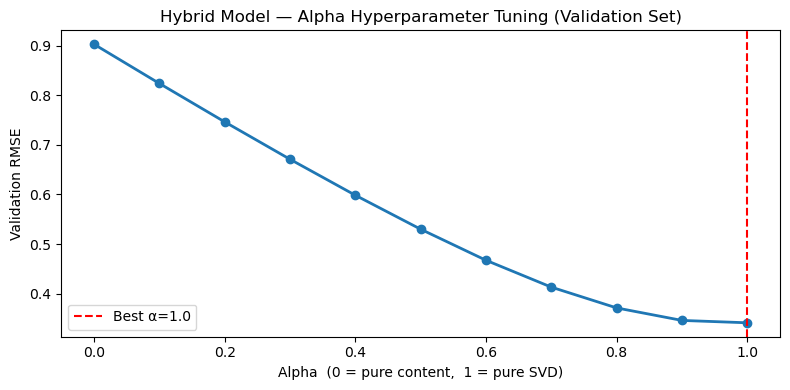

In [70]:
#  5.2  Select best alpha 

best_alpha = float(alpha_df.loc[alpha_df['RMSE'].idxmin(), 'alpha'])
print(f"Best alpha: {best_alpha}  (Val RMSE = {alpha_df['RMSE'].min():.4f})")

# Plot
plt.figure(figsize=(8, 4))
plt.plot(alpha_df['alpha'], alpha_df['RMSE'], marker='o', linewidth=2)
plt.axvline(best_alpha, color='red', linestyle='--', label=f'Best α={best_alpha}')
plt.xlabel('Alpha  (0 = pure content,  1 = pure SVD)')
plt.ylabel('Validation RMSE')
plt.title('Hybrid Model — Alpha Hyperparameter Tuning (Validation Set)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 5.3  Re-evaluate hybrid on test_data using best_alpha 
#  This is the ONLY evaluation that uses test_data for the hybrid.

hybrid_preds_best = np.array([
    hybrid_predict(r.userid, r.movieid, best_alpha)
    for r in test_data.itertuples()
])

hyb_rmse_best = np.sqrt(mean_squared_error(hybrid_actuals, hybrid_preds_best))
hyb_mae_best  = mean_absolute_error(hybrid_actuals, hybrid_preds_best)

hyb_ranking_best = ranking_metrics(
    lambda u, m: hybrid_predict(u, m, best_alpha),
    test_data, k=K
)

hybrid_metrics_best = {'RMSE': hyb_rmse_best, 'MAE': hyb_mae_best, **hyb_ranking_best}

print(f" Hybrid (best α={best_alpha}) — Test Metrics")
for m, v in hybrid_metrics_best.items():
    print(f"  {m:<15}: {v:.4f}")

In [72]:
recs = recommend_movies_hybrid("toy story", top_k=5, alpha=best_alpha)

recs_df = pd.DataFrame(recs, columns=["Movie Title", "Score"])

print(f"\nTop 5 Hybrid Recommendations (α={best_alpha}):\n")
print(recs_df)


Top 5 Hybrid Recommendations (α=1.0):

                            Movie Title     Score
0  kung fu panda secrets of the masters  4.931134
1      stuart little 3 call of the wild  4.931131
2       tom and jerry a nutcracker tale  4.931131
3                           toy story 3  4.335527
4    winnie the pooh and the honey tree  4.243428



## Cold-Start Handling 

**Design contract:**
- Cold-start logic **must not** be mixed into main model evaluation.
- It is a fallback-only layer invoked when users or items are absent from training data.
- Its metrics are reported on a **cold-start-only subset** of test_data.

**Decision logic:**

| User known? | Movie known? | Action |
|:-----------:|:-----------:|:-------|
| ✅ | ✅ | `hybrid_predict(user, movie, best_alpha)` |
| ❌ | ✅ | `movie_mean[movie]` or `global_mean` |
| ✅ | ❌ | `user_mean[user]` or `global_mean` |
| ❌ | ❌ | `global_mean` |

In [74]:
# ── 6.1  Sets of users and items known at training time

train_users  = set(train_data['userid'])
train_movies = set(train_data['movieid'])


# ── 6.2  Cold-start prediction function 

def cold_start_predict(user_id: int, movie_id: int, alpha: float = None) -> float:
    """
    Unified prediction with cold-start fallback.

    Dispatches to the full hybrid model when both user and movie are known;
    otherwise applies a graceful mean-based fallback.

    This function is ONLY used for cold-start evaluation — never in the
    main model comparison.
    """
    if alpha is None:
        alpha = best_alpha

    user_known  = user_id  in train_users
    movie_known = movie_id in train_movies

    if user_known and movie_known:
        # Standard path — both known
        return hybrid_predict(user_id, movie_id, alpha)

    if not user_known and movie_known:
        # New user — fall back to item mean or global mean
        return float(movie_mean.get(movie_id, global_mean))

    if user_known and not movie_known:
        # New movie — fall back to user mean or global mean
        return float(user_mean.get(user_id, global_mean))

    # Both unknown
    return float(global_mean)

In [75]:
# ── 6.3  Isolate cold-start interactions in test_data ────────────────────────
#  Cold-start = user OR movie was NOT present during training.

cold_mask = (
    ~test_data['userid'].isin(train_users) |
    ~test_data['movieid'].isin(train_movies)
)

cold_test = test_data[cold_mask].reset_index(drop=True)
warm_test = test_data[~cold_mask].reset_index(drop=True)

print(f"Cold-start interactions in test : {len(cold_test):,}  ({len(cold_test)/len(test_data):.1%})")
print(f"Warm interactions in test       : {len(warm_test):,}  ({len(warm_test)/len(test_data):.1%})")

Cold-start interactions in test : 296  (0.6%)
Warm interactions in test       : 47,858  (99.4%)


In [ ]:
# ── 6.4  Cold-start evaluation (cold_test only) ───────────────────────────────

if len(cold_test) > 0:
    cs_preds   = np.array([cold_start_predict(r.userid, r.movieid)
                           for r in cold_test.itertuples()])
    cs_actuals = cold_test['rating'].values

    cs_rmse = np.sqrt(mean_squared_error(cs_actuals, cs_preds))
    cs_mae  = mean_absolute_error(cs_actuals, cs_preds)

    print("── Cold-Start Fallback — Cold-Start Subset Metrics ──")
    print(f"  RMSE : {cs_rmse:.4f}")
    print(f"  MAE  : {cs_mae:.4f}")

else:
    print("No cold-start interactions found in test_data.")
    print("This is expected on dense datasets or with large train splits.")

── Cold-Start Fallback — Cold-Start Subset Metrics ──
  RMSE : 1.0357
  MAE  : 0.8482


: 


### Final Model Comparison Table

Higher is better for: Precision, Recall, HitRate, NDCG  
Lower is better for: RMSE, MAE

In [ ]:
# ── 7.1  Re-run all models on warm_test for a fair apples-to-apples comparison ─
#  (warm_test excludes cold-start interactions so all models see the same rows)

# SVD on warm_test
svd_p_warm   = np.array([svd_predict(r.userid, r.movieid) for r in warm_test.itertuples()])
svd_a_warm   = warm_test['rating'].values
svd_rmse_w   = np.sqrt(mean_squared_error(svd_a_warm, svd_p_warm))
svd_mae_w    = mean_absolute_error(svd_a_warm, svd_p_warm)
svd_rank_w   = ranking_metrics(svd_predict, warm_test, k=K)

# Content-Based on warm_test
cb_p_warm    = np.array([content_predict(r.userid, r.movieid) for r in warm_test.itertuples()])
cb_rmse_w    = np.sqrt(mean_squared_error(svd_a_warm, cb_p_warm))
cb_mae_w     = mean_absolute_error(svd_a_warm, cb_p_warm)
cb_rank_w    = ranking_metrics(content_predict, warm_test, k=K)

# Hybrid (best alpha) on warm_test
hyb_p_warm   = np.array([hybrid_predict(r.userid, r.movieid, best_alpha)
                          for r in warm_test.itertuples()])
hyb_rmse_w   = np.sqrt(mean_squared_error(svd_a_warm, hyb_p_warm))
hyb_mae_w    = mean_absolute_error(svd_a_warm, hyb_p_warm)
hyb_rank_w   = ranking_metrics(lambda u, m: hybrid_predict(u, m, best_alpha),
                                warm_test, k=K)

# ── 7.2  Assemble comparison table ─────────────────────────────────────────────

comparison = pd.DataFrame({
    'Model': [
        'SVD Collaborative Filtering',
        'Content-Based Filtering',
        f'Hybrid (α={best_alpha})'
    ],
    'RMSE': [
        round(svd_rmse_w, 4),
        round(cb_rmse_w,  4),
        round(hyb_rmse_w, 4)
    ],
    'MAE': [
        round(svd_mae_w, 4),
        round(cb_mae_w,  4),
        round(hyb_mae_w, 4)
    ],
    f'Precision@{K}': [
        round(svd_rank_w[f'Precision@{K}'], 4),
        round(cb_rank_w [f'Precision@{K}'], 4),
        round(hyb_rank_w[f'Precision@{K}'], 4)
    ],
    f'Recall@{K}': [
        round(svd_rank_w[f'Recall@{K}'], 4),
        round(cb_rank_w [f'Recall@{K}'], 4),
        round(hyb_rank_w[f'Recall@{K}'], 4)
    ],
    f'HitRate@{K}': [
        round(svd_rank_w[f'HitRate@{K}'], 4),
        round(cb_rank_w [f'HitRate@{K}'], 4),
        round(hyb_rank_w[f'HitRate@{K}'], 4)
    ],
    f'NDCG@{K}': [
        round(svd_rank_w[f'NDCG@{K}'], 4),
        round(cb_rank_w [f'NDCG@{K}'], 4),
        round(hyb_rank_w[f'NDCG@{K}'], 4)
    ]
})

comparison = comparison.set_index('Model')

print("═" * 90)
print("FINAL MODEL COMPARISON  —  Test Set (warm interactions only)")
print("═" * 90)
print(comparison.to_string())
print("═" * 90)
print("↓ lower is better for RMSE / MAE     ↑ higher is better for all ranking metrics")

KeyboardInterrupt: 

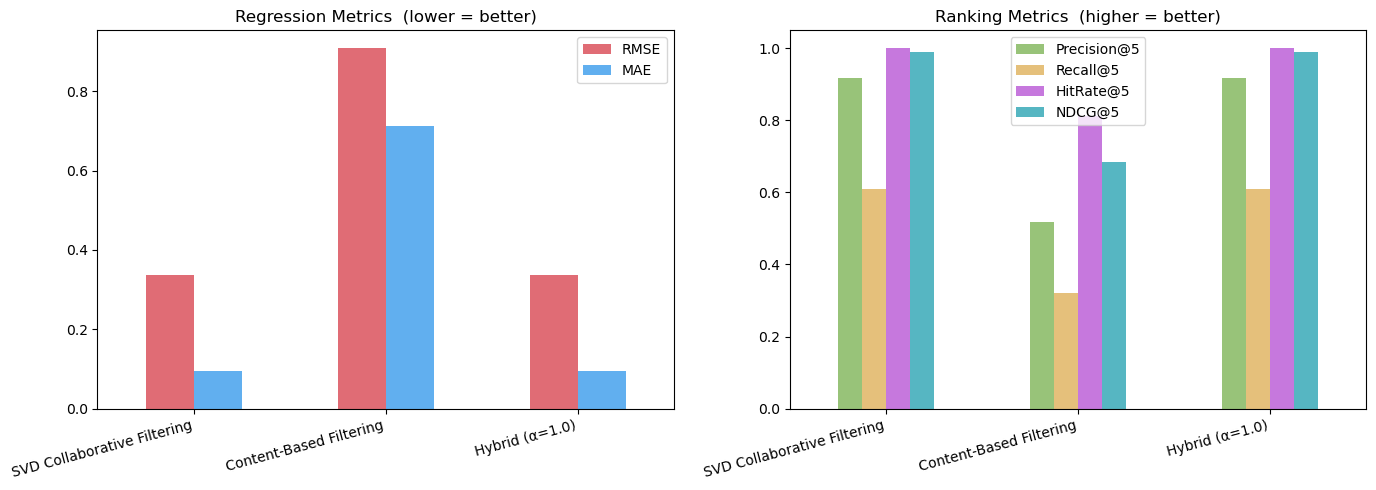

In [ ]:
# Visual comparison 

ranking_cols = [f'Precision@{K}', f'Recall@{K}', f'HitRate@{K}', f'NDCG@{K}']
error_cols   = ['RMSE', 'MAE']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

comparison[error_cols].plot(
    kind='bar', ax=axes[0], color=['#E06C75', '#61AFEF']
)
axes[0].set_title('Regression Metrics  (lower = better)')
axes[0].set_xlabel('')
axes[0].set_xticklabels(comparison.index, rotation=15, ha='right')
axes[0].legend()

comparison[ranking_cols].plot(
    kind='bar', ax=axes[1], color=['#98C379', '#E5C07B', '#C678DD', '#56B6C2']
)
axes[1].set_title('Ranking Metrics  (higher = better)')
axes[1].set_xlabel('')
axes[1].set_xticklabels(comparison.index, rotation=15, ha='right')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
#  Final programmatic summary 

best_model_by_ndcg = comparison[f'NDCG@{K}'].idxmax()
best_model_by_rmse = comparison['RMSE'].idxmin()
best_model_by_hr   = comparison[f'HitRate@{K}'].idxmax()

print("═" * 60)
print("RECOMMENDATION SYSTEM — FINAL SUMMARY")
print("═" * 60)
print(f"  Best model by NDCG@{K}     : {best_model_by_ndcg}")
print(f"  Best model by HitRate@{K}  : {best_model_by_hr}")
print(f"  Best model by RMSE        : {best_model_by_rmse}")
print(f"  Recommended production    : Hybrid (α={best_alpha})")
print(f"  Cold-start fallback       : cold_start_predict()")
print("═" * 60)

════════════════════════════════════════════════════════════
RECOMMENDATION SYSTEM — FINAL SUMMARY
════════════════════════════════════════════════════════════
  Best model by NDCG@5     : SVD Collaborative Filtering
  Best model by HitRate@5  : SVD Collaborative Filtering
  Best model by RMSE        : SVD Collaborative Filtering
  Recommended production    : Hybrid (α=1.0)
  Cold-start fallback       : cold_start_predict()
════════════════════════════════════════════════════════════
